# Seasonal Stage1: λ=2 vs λ=10 vs λ=15


In [1]:

from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# --- Config -----------------------------------------------------------------
YEAR = 1985

RUNS = {
    "lambda2": "stagel_3month_cap",
    "lambda10": "stagel_3month_λ_10",
    "lambda15": "stagel_3month_paremeter_λ_15_paremeter_on",
}

# output_root (robust when running from analysis folder)
output_root = Path("acorn-julia/runs/low_RE_mod_elec_iter0/outputs/historical_1980_2019")
if not output_root.exists():
    output_root = Path.cwd().parent / "outputs" / "historical_1980_2019"

print("Year:", YEAR)
print("Runs:", RUNS)
print("output_root:", output_root)


Year: 1985
Runs: {'lambda2': 'stagel_3month_cap', 'lambda10': 'stagel_3month_λ_10', 'lambda15': 'stagel_3month_paremeter_λ_15_paremeter_on'}
output_root: /home/fs01/jl2966/acorn-julia2/acorn-julia/runs/low_RE_mod_elec_iter0/outputs/historical_1980_2019


In [2]:

# --- Helpers ----------------------------------------------------------------

def _strip_tz(idx):
    if hasattr(idx, 'tz') and idx.tz is not None:
        return idx.tz_convert(None)
    return idx


def tidy_storage_df(df: pd.DataFrame, value_name: str) -> pd.DataFrame:
    meta_cols = [c for c in ["bus_id", "asset_type", "zone", "is_seasonal"] if c in df.columns]
    value_cols = [c for c in df.columns if c not in meta_cols]
    tidy = df.melt(id_vars=meta_cols, value_vars=value_cols,
                   var_name="timestamp", value_name=value_name)
    tidy["timestamp"] = pd.to_datetime(tidy["timestamp"], errors="coerce")
    tidy = tidy.dropna(subset=["timestamp"])
    tidy[value_name] = pd.to_numeric(tidy[value_name], errors="coerce").fillna(0.0)
    return tidy


def tidy_bus_df(path: Path, value_name: str) -> pd.DataFrame:
    df = pd.read_csv(path)
    meta_cols = [c for c in ["bus_id", "zone"] if c in df.columns]
    value_cols = [c for c in df.columns if c not in meta_cols]
    tidy = df.melt(id_vars=meta_cols, value_vars=value_cols,
                   var_name="timestamp", value_name=value_name)
    tidy["timestamp"] = pd.to_datetime(tidy["timestamp"], errors="coerce")
    tidy = tidy.dropna(subset=["timestamp"])
    tidy[value_name] = pd.to_numeric(tidy[value_name], errors="coerce").fillna(0.0)
    return tidy


def total_ts(df: pd.DataFrame, value_name: str) -> pd.Series:
    return df.groupby("timestamp")[value_name].sum()


def load_seasonal_soc(run_dir: Path, year: int) -> pd.Series:
    p = run_dir / f"storage_state_seasonal_{year}.csv"
    if not p.exists():
        return pd.Series(dtype=float)
    df = pd.read_csv(p)
    if df.empty:
        return pd.Series(dtype=float)
    cols = [c for c in df.columns if c not in ("zone",)]
    df = df[cols]
    if not df.empty and df.iloc[0, 0] == "bus_id":
        df = df.iloc[1:]
    value_cols = [c for c in df.columns if c != "bus_id"]
    df[value_cols] = df[value_cols].apply(pd.to_numeric, errors="coerce")
    soc = df[value_cols].sum(axis=0)
    soc.index = pd.to_datetime(soc.index, errors="coerce")
    soc = soc.dropna()
    if hasattr(soc.index, 'tz') and soc.index.tz is not None:
        soc.index = soc.index.tz_convert(None)
    return soc


def safe_sum(series: pd.Series) -> float:
    return pd.to_numeric(series, errors="coerce").fillna(0.0).sum()


In [3]:

# --- Load all runs ----------------------------------------------------------
run_data = {}
for label, name in RUNS.items():
    run_dir = output_root / name
    run_data[label] = {
        "charge_base": tidy_storage_df(pd.read_csv(run_dir / f"charge_base_{YEAR}.csv"), "charge"),
        "discharge_base": tidy_storage_df(pd.read_csv(run_dir / f"discharge_base_{YEAR}.csv"), "discharge"),
        "charge_seasonal": tidy_storage_df(pd.read_csv(run_dir / f"charge_seasonal_{YEAR}.csv"), "charge"),
        "discharge_seasonal": tidy_storage_df(pd.read_csv(run_dir / f"discharge_seasonal_{YEAR}.csv"), "discharge"),
        "load_shed": tidy_bus_df(run_dir / f"load_shedding_{YEAR}.csv", "load_shedding"),
        "wind_curt": tidy_bus_df(run_dir / f"wind_curtailment_{YEAR}.csv", "wind_curtailment"),
        "solar_curt": tidy_bus_df(run_dir / f"solar_curtailment_{YEAR}.csv", "solar_curtailment"),
        "soc_seasonal": load_seasonal_soc(run_dir, YEAR),
    }

print("Loaded:", list(run_data.keys()))


Loaded: ['lambda2', 'lambda10', 'lambda15']


## A) Annual totals (energy, curtailment, load shedding)


In [4]:

rows = []
for label, data in run_data.items():
    base_dis = total_ts(data["discharge_base"], "discharge")
    seas_dis = total_ts(data["discharge_seasonal"], "discharge")
    base_ch = total_ts(data["charge_base"], "charge")
    seas_ch = total_ts(data["charge_seasonal"], "charge")
    ls = total_ts(data["load_shed"], "load_shedding")
    wind = total_ts(data["wind_curt"], "wind_curtailment")
    solar = total_ts(data["solar_curt"], "solar_curtailment")

    rows.append({
        "run": label,
        "base_charge_MWh": safe_sum(base_ch),
        "base_discharge_MWh": safe_sum(base_dis),
        "seasonal_charge_MWh": safe_sum(seas_ch),
        "seasonal_discharge_MWh": safe_sum(seas_dis),
        "load_shed_MWh": safe_sum(ls),
        "wind_curt_MWh": safe_sum(wind),
        "solar_curt_MWh": safe_sum(solar),
    })

summary = pd.DataFrame(rows)
for c in summary.columns[1:]:
    summary[c] = summary[c].round(2)

display(summary)


,run,base_charge_MWh,base_discharge_MWh,seasonal_charge_MWh,seasonal_discharge_MWh,load_shed_MWh,wind_curt_MWh,solar_curt_MWh
0,lambda2,5424724.62,4072014.56,13727317.04,13662535.04,608077.86,1424841.10,3122753.10
1,lambda10,6772953.56,5083186.27,11890741.91,12282806.41,608077.86,1409691.37,3262905.44
2,lambda15,6903529.12,5181117.94,11776321.53,12142318.07,608077.86,1414353.44,3204267.02


## B) Storage activity (base vs seasonal)


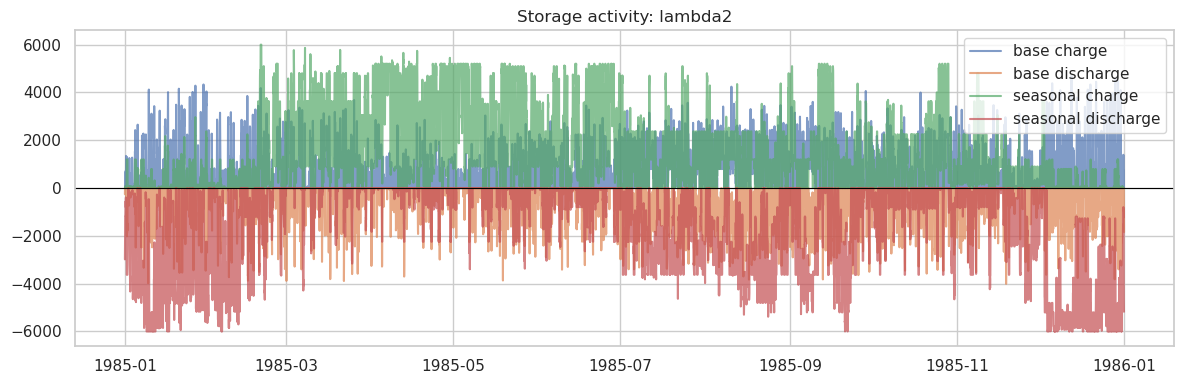

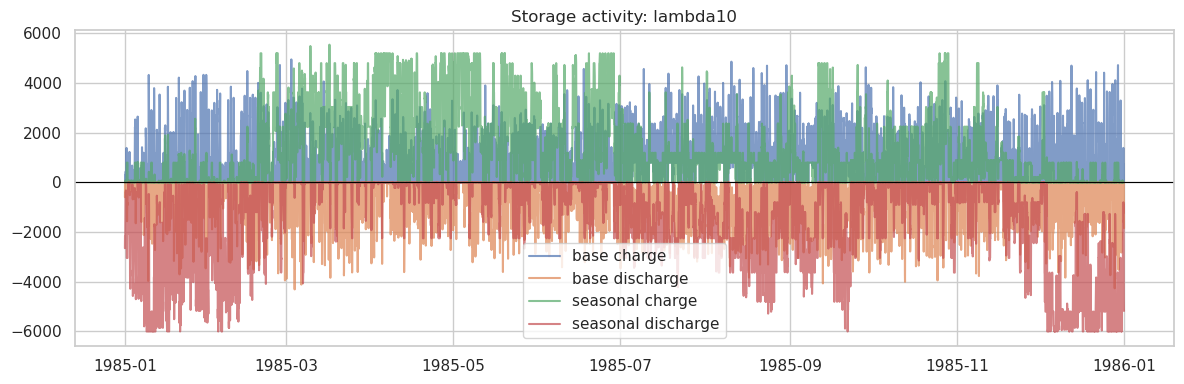

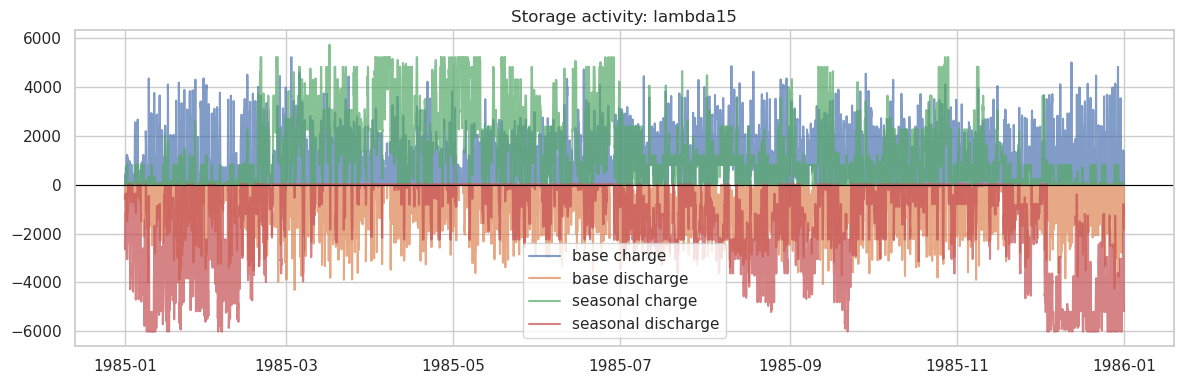

In [5]:

for label, data in run_data.items():
    base_ch = total_ts(data["charge_base"], "charge")
    base_dis = total_ts(data["discharge_base"], "discharge")
    seas_ch = total_ts(data["charge_seasonal"], "charge")
    seas_dis = total_ts(data["discharge_seasonal"], "discharge")

    fig, ax = plt.subplots(1, 1, figsize=(12,4))
    ax.plot(base_ch.index, base_ch.values, label="base charge", alpha=0.7)
    ax.plot(base_dis.index, -base_dis.values, label="base discharge", alpha=0.7)
    ax.plot(seas_ch.index, seas_ch.values, label="seasonal charge", alpha=0.7)
    ax.plot(seas_dis.index, -seas_dis.values, label="seasonal discharge", alpha=0.7)
    ax.axhline(0.0, color="black", linewidth=0.8)
    ax.set_title(f"Storage activity: {label}")
    ax.legend()
    plt.tight_layout()
    plt.show()


## C) Load shedding (time series + top buses)


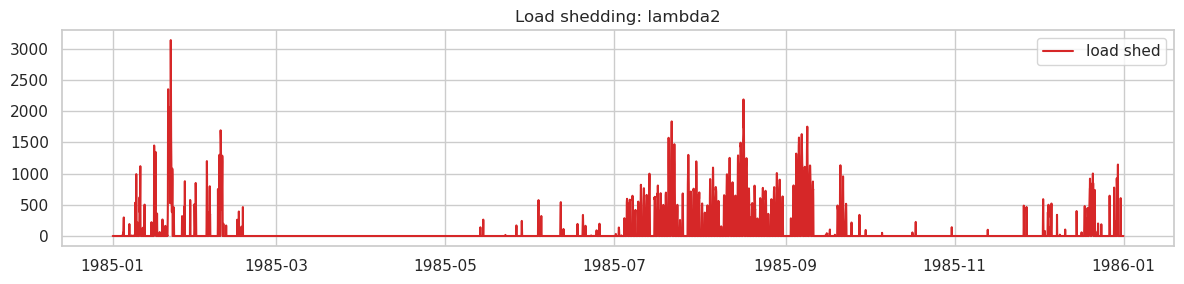

lambda2 – top 15 shedding buses


,bus_id,load_shedding
0,80,603635.993963
1,75,1820.830471
2,77,1583.009121
3,76,1038.027078
4,37,0.000000
5,38,0.000000
6,43,0.000000
7,44,0.000000
8,45,0.000000
9,46,0.000000


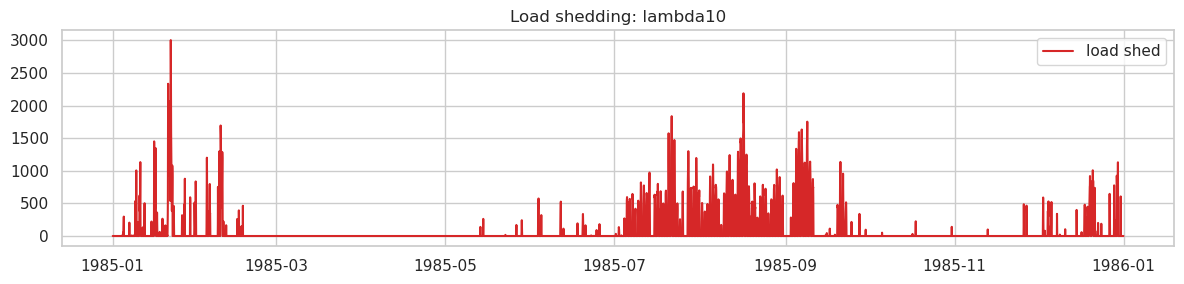

lambda10 – top 15 shedding buses


,bus_id,load_shedding
0,80,603635.993963
1,75,2093.478660
2,77,1306.285226
3,76,1042.102667
4,37,0.000000
5,38,0.000000
6,43,0.000000
7,44,0.000000
8,45,0.000000
9,46,0.000000


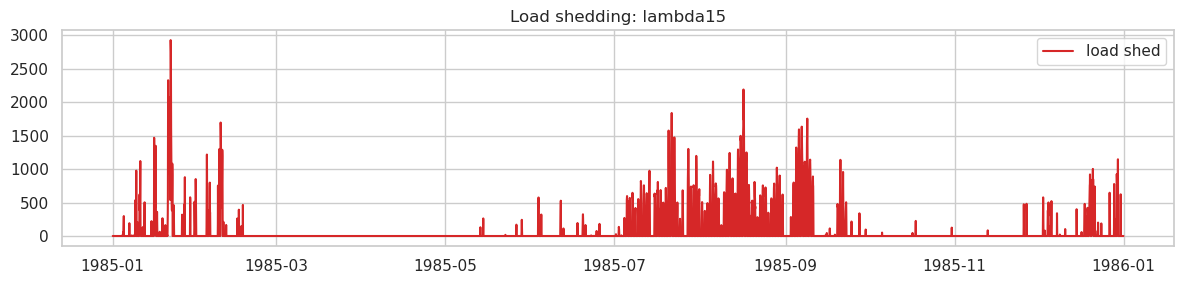

lambda15 – top 15 shedding buses


,bus_id,load_shedding
0,80,603635.993963
1,75,2157.861993
2,77,1306.285226
3,76,977.719335
4,37,0.000000
5,38,0.000000
6,43,0.000000
7,44,0.000000
8,45,0.000000
9,46,0.000000


In [6]:

for label, data in run_data.items():
    ls = total_ts(data["load_shed"], "load_shedding")
    fig, ax = plt.subplots(1, 1, figsize=(12,3))
    ax.plot(ls.index, ls.values, label="load shed", color="tab:red")
    ax.set_title(f"Load shedding: {label}")
    ax.legend()
    plt.tight_layout()
    plt.show()

    ls_bus = data["load_shed"].groupby("bus_id")["load_shedding"].sum().sort_values(ascending=False).head(15)
    print(f"{label} – top 15 shedding buses")
    display(ls_bus.reset_index())


## D) Curtailment (wind + solar)


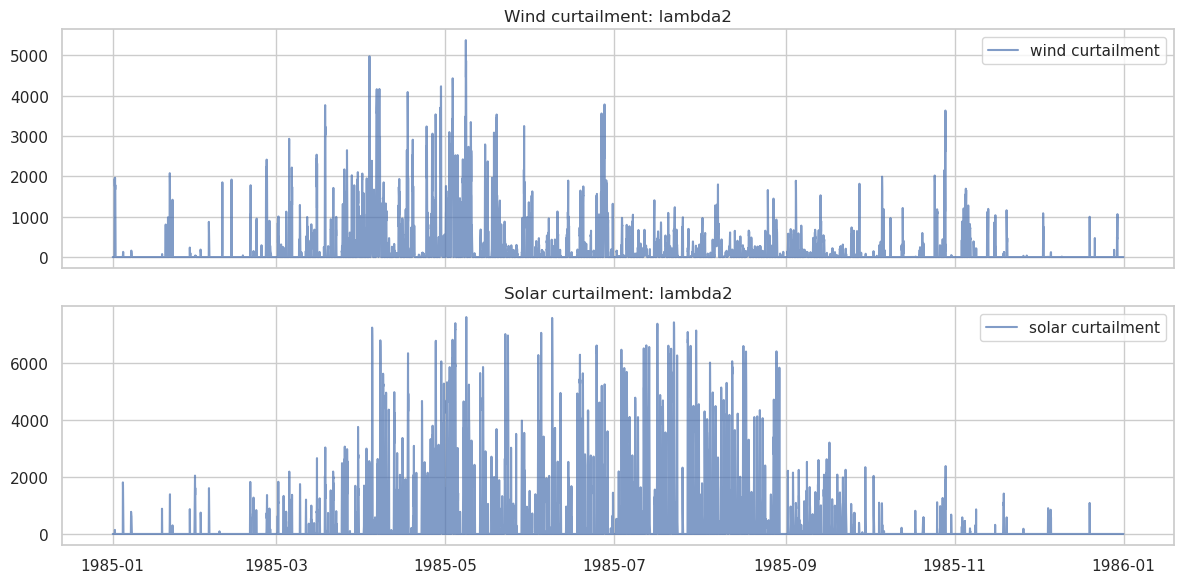

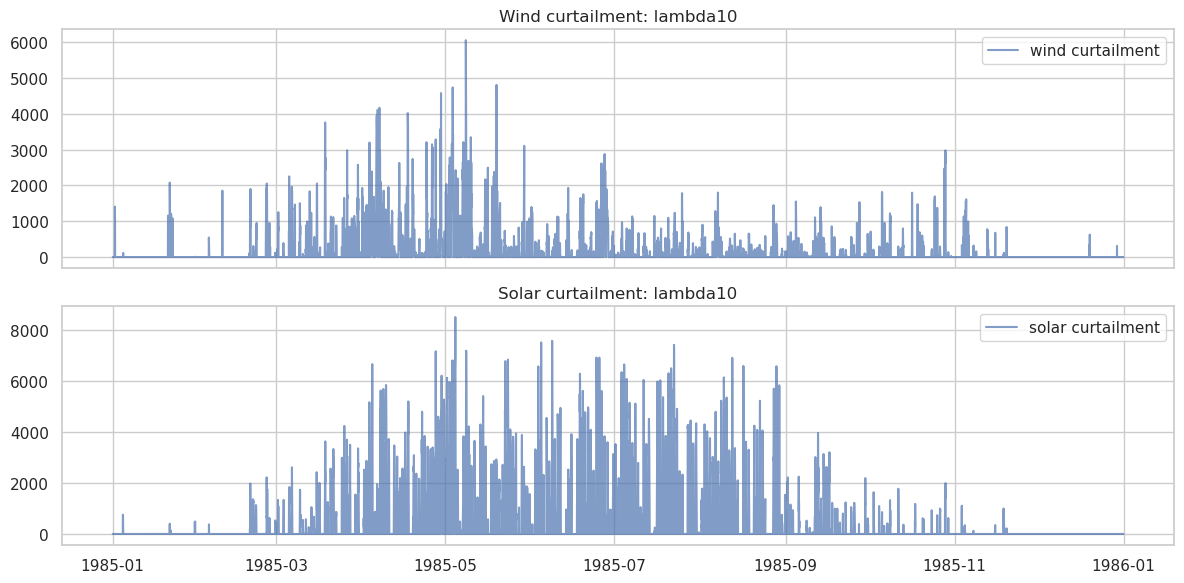

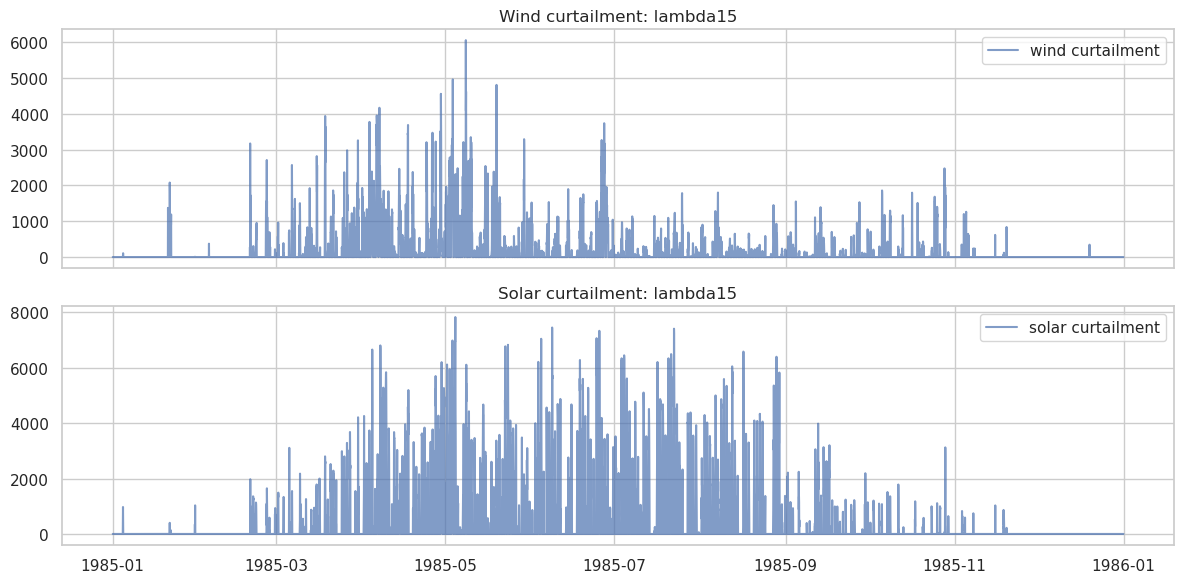

In [7]:

for label, data in run_data.items():
    wind = total_ts(data["wind_curt"], "wind_curtailment")
    solar = total_ts(data["solar_curt"], "solar_curtailment")

    fig, axes = plt.subplots(2, 1, figsize=(12,6), sharex=True)
    axes[0].plot(wind.index, wind.values, label="wind curtailment", alpha=0.7)
    axes[0].set_title(f"Wind curtailment: {label}")
    axes[0].legend()

    axes[1].plot(solar.index, solar.values, label="solar curtailment", alpha=0.7)
    axes[1].set_title(f"Solar curtailment: {label}")
    axes[1].legend()

    plt.tight_layout()
    plt.show()


## E) Seasonal SOC stats + monthly seasonality


,run,soc_max_MWh,soc_min_MWh,soc_end_MWh
0,lambda2,6297680.27,0.00,0.00
1,lambda10,5918516.33,2652.68,2652.68
2,lambda15,5891999.07,65783.68,65783.68


Monthly net seasonal energy (MWh):


,lambda2,lambda10,lambda15
timestamp,,,
1985-01-31,-2139586.4,-2112681.0,-2107945.6
1985-02-28,-650274.3,-656530.8,-655973.7
1985-03-31,1538829.3,1461087.2,1450611.3
1985-04-30,2153896.9,2021693.7,2009749.9
1985-05-31,1871976.5,1746105.2,1739683.3
1985-06-30,1447640.7,1258010.5,1242639.0
1985-07-31,-441335.6,-403866.2,-379230.4
1985-08-31,-940478.7,-865221.4,-831202.8
1985-09-30,-269842.1,-254609.5,-245480.4


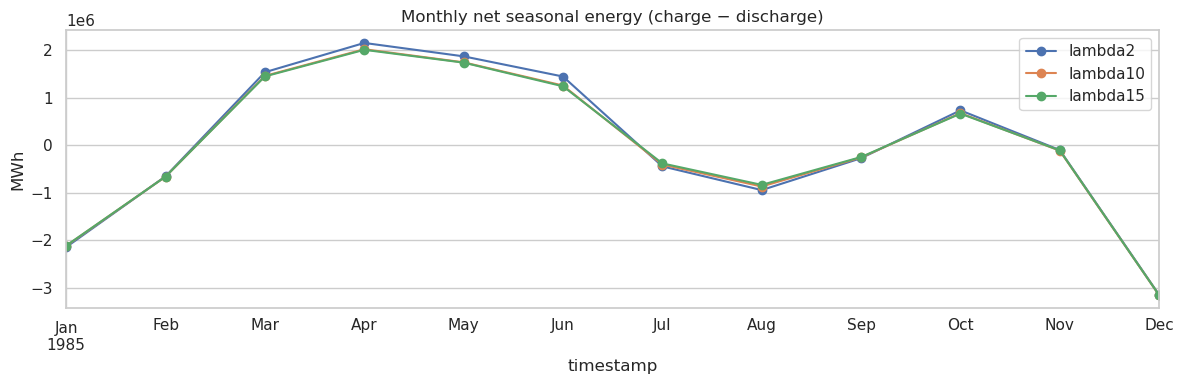

Monthly mean seasonal SOC (MWh):


,lambda2,lambda10,lambda15
1985-01-31,2628252.5,2662355.3,2666451.6
1985-02-28,572295.5,635067.3,643490.7
1985-03-31,1058927.5,1087943.6,1093622.9
1985-04-30,2702914.5,2651843.9,2643382.6
1985-05-31,4439324.2,4290102.7,4281958.7
1985-06-30,5587389.9,5295010.4,5275346.5
1985-07-31,5927856.3,5607136.2,5598509.1
1985-08-31,4797668.1,4664698.3,4686666.4
1985-09-30,3743148.7,3730222.8,3776812.3
1985-10-31,3681921.4,3671180.3,3718325.1


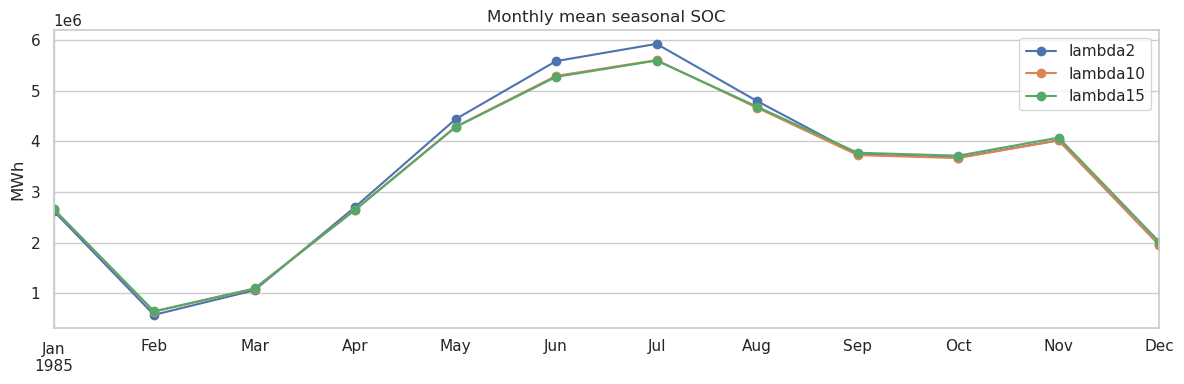

In [8]:

rows = []
for label, data in run_data.items():
    soc = data["soc_seasonal"]
    if soc.empty:
        rows.append({"run": label, "soc_max_MWh": np.nan, "soc_min_MWh": np.nan, "soc_end_MWh": np.nan})
        continue
    rows.append({
        "run": label,
        "soc_max_MWh": float(soc.max()),
        "soc_min_MWh": float(soc.min()),
        "soc_end_MWh": float(soc.iloc[-1]),
    })

soc_df = pd.DataFrame(rows)
for c in soc_df.columns[1:]:
    soc_df[c] = soc_df[c].round(2)

display(soc_df)

# Monthly net energy + SOC

def monthly_sum(series: pd.Series) -> pd.Series:
    if series is None or len(series) == 0:
        return pd.Series(dtype=float)
    s = series.copy()
    s.index = _strip_tz(s.index)
    return s.resample("ME").sum()


def monthly_mean(series: pd.Series) -> pd.Series:
    if series is None or len(series) == 0:
        return pd.Series(dtype=float)
    s = series.copy()
    s.index = _strip_tz(s.index)
    return s.resample("ME").mean()

monthly_net = {}
monthly_soc = {}
for label, data in run_data.items():
    seas_ch = total_ts(data["charge_seasonal"], "charge")
    seas_dis = total_ts(data["discharge_seasonal"], "discharge")
    net = seas_ch - seas_dis
    monthly_net[label] = monthly_sum(net)
    monthly_soc[label] = monthly_mean(data["soc_seasonal"])

monthly_net_df = pd.DataFrame(monthly_net).sort_index()
monthly_soc_df = pd.DataFrame(monthly_soc).sort_index()

print("Monthly net seasonal energy (MWh):")
display(monthly_net_df.round(1))

plot_net = monthly_net_df.dropna(how="all", axis=1)
if not plot_net.empty:
    ax = plot_net.plot(figsize=(12,4), marker='o', title="Monthly net seasonal energy (charge − discharge)")
    ax.set_ylabel("MWh")
    plt.tight_layout()
    plt.show()

print("Monthly mean seasonal SOC (MWh):")
display(monthly_soc_df.round(1))

plot_soc = monthly_soc_df.dropna(how="all", axis=1)
if not plot_soc.empty:
    ax = plot_soc.plot(figsize=(12,4), marker='o', title="Monthly mean seasonal SOC")
    ax.set_ylabel("MWh")
    plt.tight_layout()
    plt.show()
